# Pyrato Introduction

**[Pyrato](https://pyrato.readthedocs.io)** (**Py**thon **R**oom **A**coustics **To**ols) is a collection of functions for commonly used operations in room acoustics. It is part of the [pyfar](https://pyfar.org) ecosystem of Python packages for acoustics research.

The **pyrato package** contains classes and functions for commonly used operations in room acoustics.

We develop all packages openly across diverse research institutions, avoiding general branding of code or functionality. Contributions (in any form, i.e. reporting issues, submitting bug-fixes or implementation of new features) are welcome.
To get in touch, either contact us via

- [GitHub](https://github.com/pyfar).
- [Join the Slack channel](https://join.slack.com/t/pyfar/shared_invite/zt-2eacdhww2-iUiPnh_wuqg2zD939wL4kw).
- Write an old-school e-mail to info@pyfar.org.

## Example Gallery

This notebook, among others, is part of [pyfar's example gallery](https://pyfar-gallery.readthedocs.io/en/latest/).
The gallery contains:

- Notebooks supplementary to the [documentation](https://pyfar.readthedocs.io/en/stable).
- Application examples giving an overview over the use cases pyfar and its sub-packages.

All examples can either be 

- viewed as statically rendered web-pages,
- interactively executed on mybinder.org,
- downloaded and run locally.

The respective links are located at the top of each example notebook. 

To follow along with the workshop document, either navigate to [pyfar.org](https://pyfar.org) and scroll down to the **Workshops** section and select the **pyrato introduction**.


In [27]:
# import packages
import pyfar as pf
import pyrato 
import numpy as np
import matplotlib.pyplot as plt
from pyfar.plot.ticker import FractionalOctaveLocator
from matplotlib.ticker import EngFormatter, NullFormatter

# set matplotlib backend for plotting
%matplotlib widget

# Room Acoustic Parameter Calculation Using Pyrato

This notebook introduces **Pyrato**, a room‑acoustics toolbox, and demonstrates how to calculate standard room acoustic parameters from a measured room impulse response. The analysis uses a real room impulse response (RIR) recorded in the Berliner Philharmonie, preserving the full decay to capture the authentic acoustics of the hall. The measured RIR is pre‑processed by bandpass filtering into octave bands and visualized (including interactive plots) to inspect the time‑domain structure in each band. On this basis, the notebook computes key parameters such as the Energy Decay Curve (EDC), reverberation time T20, clarity C80, and Speech Transmission Index (STI), illustrating a complete workflow from loading the broadband RIR measurement to parameter evaluation within the pyrato ecosystem.

For our investigations, we use a real room impulse response (RIR) provided by the [pyfar.signlas.files](https://pyfar.readthedocs.io/en/stable/modules/pyfar.signals.files.html#) module.

This RIR was measured in the Berliner Philharmonie, a world-famous concert hall in Berlin, Germany. It was recorded using a high-quality microphone and sound source, capturing the hall’s unique acoustic signature.

Loading the RIR via [pyfar.signals.files.room_impulse_response](https://pyfar.readthedocs.io/en/stable/modules/pyfar.signals.files.html#pyfar.signals.files.room_impulse_response) returns a `pyfar.Signal` object, which:

- Stores the time-domain impulse response
- Preserves the entire decay, including the late reverberant tail
- Supports multi-channel signals (e.g., stereo or array measurements)
- Integrates sampling rate and meta-data

The RIR is part of the example signals provided by the `pyfar.signals.files` module. To load the data, run the following cell

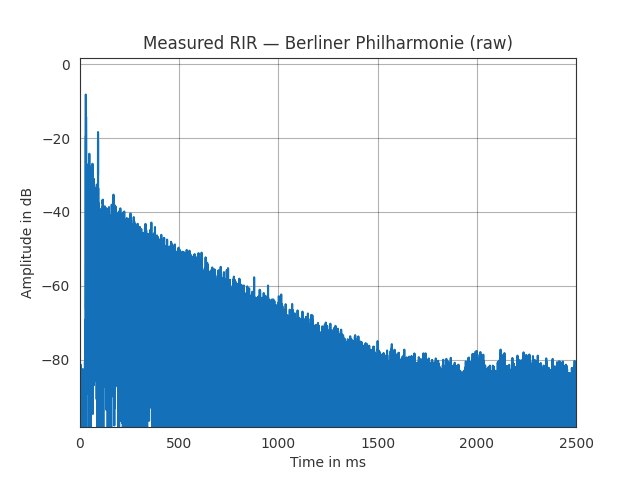

In [28]:
rir = pf.signals.files.room_impulse_response(
    sampling_rate=48000, 
    crop_noise_tail=False)

plt.figure()
pf.plot.time(rir, unit='ms', dB=True)
plt.title("Measured RIR — Berliner Philharmonie (raw)")
plt.show()

## Pre-Processing

For frequency-dependent room acoustic analysis, the RIR is filtered into octave bands using [pyfar.dsp.filter.fractional_octave_bands](https://pyfar.readthedocs.io/en/stable/modules/pyfar.dsp.filter.html#pyfar.dsp.filter.fractional_octave_bands). This returns a multi-channel Signal where each channel corresponds to one octave band (e.g., 125 Hz, 250 Hz, 500 Hz, etc.), enabling separate analysis of how the Berliner Philharmonie's acoustics vary across the frequency spectrum.

Before filtering, the RIR is aligned by detecting the first sample which is below the threshold level relative to the maximum level of the impulse response and shifting the impulse start to $t=0$ using [pyfar.dsp.find_impulse_response_start](https://pyfar.readthedocs.io/en/stable/modules/pyfar.dsp.html#pyfar.dsp.find_impulse_response_start) and [pyfar.dsp.time_shift](https://pyfar.readthedocs.io/en/stable/modules/pyfar.dsp.html#pyfar.dsp.time_shift).

The Philharmonie RIR is split into these standard ISO octave bands. This pre-processing step is essential because parameters like T20, C80, and STI are computed per frequency band to capture the hall's frequency-dependent behavior.

In [29]:
start_sample = pf.dsp.find_impulse_response_start(rir)
rir_shifted = pf.dsp.time_shift(rir, -start_sample, mode='linear')

rir_octave_bands  = pf.dsp.filter.fractional_octave_bands(
    rir_shifted, num_fractions=1, frequency_range=(125, 4000))
octave_bands  = pf.constants.fractional_octave_frequencies_nominal(
    num_fractions=1, frequency_range=(125, 4000))


## Room Acoustic Parameters
Room acoustic parameters quantify the perceptual quality of a room for music and speech. The [pyrato.parameters](https://pyrato.readthedocs.io/en/stable/modules/parameters.html) module provides implementations of ISO 3382 parameters calculated directly from the RIR or its octave-band filtered versions.

#### Lundeby's Method 
Lundeby et al. [2] proposed a noise compensation method, where the RIR is truncated to the intersection time $t_i$ and additionally intruced a correction term $C_\mathrm{Comp}$.

$$ E(t) = \int_t^{t_i} h^2(\tau) d\tau + C_\mathrm{Comp}  $$

$$C_\mathrm{Comp} = p_{i}^2 \cdot T_{60, \mathrm{late}} \cdot \frac{1}{6 \cdot ln(10)} \cdot R_s $$

$p_{i}^2$ denotes the squared sound pressure at the intersection time, $T_{60, \mathrm{late}}$ the late reverberation time after Lundeby and $R_\mathrm{s}$ the sampling rate.

This is implemented in [pyrato.edc.energy_decay_curve_lundeby](https://pyrato.readthedocs.io/en/stable/modules/edc.html#pyrato.edc.energy_decay_curve_lundeby).

In [30]:
edc_lundeby =  pyrato.edc.energy_decay_curve_lundeby(
        rir_octave_bands,
        freq='broadband',
        noise_level='auto',
        is_energy=False,
        time_shift=True,
        channel_independent=True,
        normalize=True,
        plot=False)

The [pyrato.edc.energy_decay_curve_lundeby](https://pyrato.readthedocs.io/en/stable/modules/edc.html#pyrato.edc.energy_decay_curve_lundeby) method returns a [pyfar.TimeData](https://pyfar.readthedocs.io/en/stable/classes/pyfar.audio.html#pyfar.TimeData) Object, that allows us to plot directly and inspected interactively. 

The Pyfar provides convenient **keyboard shortcuts** for switching between channels, zooming, and panning.

**All following figures support interactive shortcuts.** If the plot does not respond, click the figure first to activate it.

Use `,` / `.` (DE keyboard) or `[` / `]` (EN keyboard) to cycle through octave bands. `Shift + a` toggles between showing all channels and a single channel.

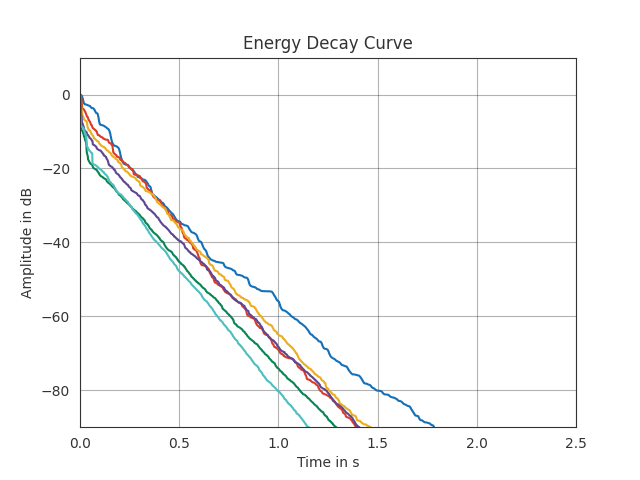

In [31]:
plt.figure()
pf.plot.time(edc_lundeby, unit='s', dB=True)
plt.title(f"Energy Decay Curve")
plt.show()

### Reverberation Time T20

Reverberation time T20 measures how long it takes for sound to decay by 60 dB after the source stops. T20 fits a regression line to the −5 dB to −25 dB range of the EDC (optimal SNR region) and extrapolates to −60 dB ([pyrato.parameters.reverberation_time()](https://pyrato.readthedocs.io/en/stable/modules/parameters.html#reverberation_time_linear_regression)).

In [32]:
T20 = pyrato.parameters.reverberation_time_linear_regression(edc_lundeby,T='T20',return_intercept=False)
print("Octave band center frequencies in Hz:", octave_bands)
print("\nReverberation time T20 in s:\n", np.squeeze(np.round(T20, 2)))

Octave band center frequencies in Hz: [ 125.  250.  500. 1000. 2000. 4000.]

Reverberation time T20 in s:
 [2.15 1.8  2.05 2.03 1.95 1.71]


Now, to plot T20 over our octave band center frequenciea we can simply create a [pyfar.FrequencyData()](https://pyfar.readthedocs.io/en/stable/classes/pyfar.audio.html#pyfar.FrequencyData) type object and plot it directly in pyfar.

Text(0.5, 1.0, 'Reverberation Time T20 in Octave Bands')

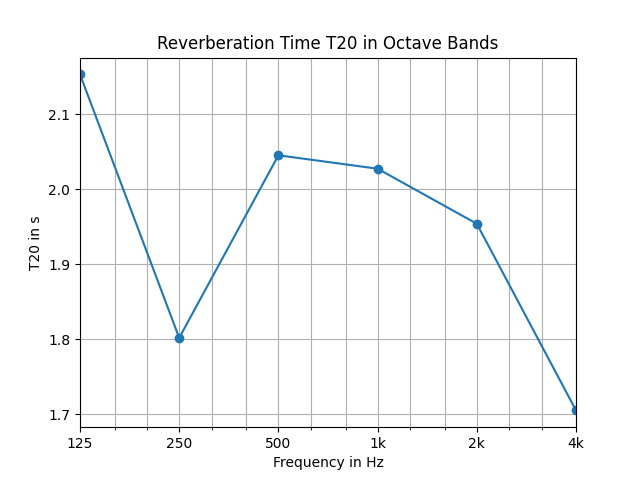

In [33]:
T20_FrequencyData = pf.FrequencyData(T20[:, 0], octave_bands)

plt.figure()
ax = plt.axes()
pf.plot.freq(T20_FrequencyData,marker='o', dB=False, ax=ax)
ax.xaxis.set_major_locator(FractionalOctaveLocator(n_fractions=1))
ax.xaxis.set_major_formatter(EngFormatter(unit='', sep=''))
ax.xaxis.set_minor_locator(FractionalOctaveLocator(n_fractions=3))
ax.xaxis.set_minor_formatter(NullFormatter())

plt.xlabel('Frequency in Hz')
plt.ylabel('T20 in s')
plt.title('Reverberation Time T20 in Octave Bands')

### Clarity C80

Parameter Clarity is frequently used for measuring intelligibility and musical definition. It quantifies the balance between early (first 80 ms: direct sound + early reflections) and late reverberation energy via their logarithmic ratio: 

$$
C_{80} = 10 \log_{10}
\left(
\frac{
\displaystyle \int_{0}^{80} p^2(t)\,\mathrm{d}t
}{
\displaystyle \int_{80}^{\infty} p^2(t)\,\mathrm{d}t
}
\right)
$$

In pyrato, all energy based room acoustic parameters are computed from the EDC. For ([pyrato.parameters.clarity](https://pyrato.readthedocs.io/en/stable/modules/parameters.html#clarity)) this can be done using the following expression:

$$
C_{80} = 10 \log_{10} \left( \frac{E(0)}{E(80)} - 1 \right),
$$

For flexibility we also allow different time limits. So calculation of a $C_{\mathrm{limit}}$ with every possible limit in milliseconds is possible. 

We calculate the **C80** for our previously computed **octave bands** EDCs with the early time limit in milliseconds: 

In [34]:
C80_octave_bands = pyrato.parameters.clarity(
    edc_lundeby,
    early_time_limit=80
)

print("Octave band center frequencies in Hz:", octave_bands)
print("\nClarity C80 in dB:\n", np.squeeze(np.round(C80_octave_bands, 2)))

Octave band center frequencies in Hz: [ 125.  250.  500. 1000. 2000. 4000.]

Clarity C80 in dB:
 [-1.15  3.19  4.92  6.08  9.68  9.11]


#### Single number frequency averaging

Typically, rooms are compared using the single-digit value specified in ISO 3382-2. 

Accordingly, the average should be taken over the 500 Hz and 1 kHz octave bands.

In [35]:
C80_single_number = np.mean(C80_octave_bands[2:4])
print(f"\nClarity C80 single number: {C80_single_number.item():.2f} dB",)


Clarity C80 single number: 5.50 dB


### Speech Transmission Index 

The Speech Transmission Index (STI) quantifies speech intelligibility on a scale from 0 (unintelligible) to 1 (perfect). It measures how well the temporal amplitude modulations of speech are preserved when transmitted through a room or audio system. STI is calculated by analyzing the modulation transfer across seven octave bands (125 Hz – 8 kHz) and 14 defined modulation frequencies (≈0.5–16 Hz). Room reflections, reverberation, and background noise reduce modulation depth, lowering STI values.

In pyrato, the [pyrato.parameters.speech_transmission_index_indirect()](https://pyrato.readthedocs.io/en/stable/modules/parameters.html#speech_transmission_index_indirect) function can compute STI directly from a room impulse response (RIR) without additional specific test signals.


We load measurements for typical male speech (65 dB(A), IEC 60268-16:2020 Annex B) and background noise representative of an unoccupied auditorium (NC-20, ANSI/ASA S12.2-2019). We compute the SNR simply by subtracting the noise from the signal level.

In [36]:
level = np.array([68, 68, 64, 63, 52, 46, 40])   
noise_level = np.array([40, 33, 26, 22, 19, 17, 16]) 

snr = level - noise_level

Then, we can simply calculate the STI with pyrato and format the result numpy-like.

In [37]:
sti = pyrato.parameters.speech_transmission_index_indirect(
    rir,
    rir_type="acoustical",
    level=level,
    snr=snr,
    ambient_noise_correction=True,
) #.item()

print(f"Speech Transmission Index (STI): {sti.item():.2f}")


Speech Transmission Index (STI): 0.69


# License notice
This notebook © 2024 by [the pyfar developers](https://github.com/orgs/pyfar/people) is licensed under [CC BY 4.0](http://creativecommons.org/licenses/by/4.0/?ref=chooser-v1)

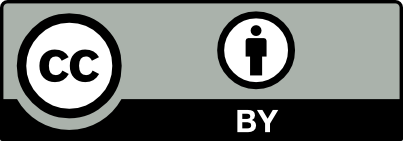


# Watermark

In [38]:
%load_ext watermark
%watermark -v -m -iv

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Python implementation: CPython
Python version       : 3.11.9
IPython version      : 9.10.0

Compiler    : Clang 13.0.0 (clang-1300.0.29.30)
OS          : Darwin
Release     : 25.3.0
Machine     : arm64
Processor   : arm
CPU cores   : 10
Architecture: 64bit

matplotlib: 3.10.8
numpy     : 2.4.3
pyfar     : 0.8.0
pyrato    : 0.4.2

